# 01 - Data audit: NHIS 2025 Sample Adult

## Objective

Validate whether the NHIS 2025 Sample Adult dataset supports the analysis of high-impact chronic pain and identify the variables relevant to the project.

The framing, research questions and analysis plan are in docs/business-case.md.

## Setup

In [1]:
import sys
sys.path.append("..")

import pandas as pd

from src.hicp import (
    flag_chronic_pain,
    flag_hicp,
    flag_cohort,
    recode_invalid_to_nan,
    PAIN_INVALID_CODES,
)

df = pd.read_csv("../data/raw/adult25csv/adult25.csv", low_memory=False)

In [2]:
df.shape

(24215, 577)

*it confirms the 24_215 observations mentioned in the readme of the authors' dataset*

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24215 entries, 0 to 24214
Columns: 577 entries, RATCAT_A to POVRATTC_A
dtypes: float64(380), int64(196), object(1)
memory usage: 106.6+ MB


In [4]:
display(df.head(20))

,RATCAT_A,INCTCFLG_A,IMPINCFLG_A,HISPALLP_A,RACEALLP_A,ANYDIFF_A,DISAB3_A,SCHDYMSSTC_A,AFNOW,PHQCAT_A,...,LSATIS4_A,PHSTAT_A,HHSTAT_A,RECTYPE,IMPNUM_A,ADHDAGETC_A,WPHINDEX_A,WTFA_A,HHX,POVRATTC_A
0,6,0,1,2,1,1,1,NaN,NaN,3,...,2,3,1,10,1,NaN,26,10636.862,H012128,1.58
1,12,0,1,3,2,1,2,NaN,NaN,1,...,1,4,1,10,1,NaN,34,2996.860,H000617,4.32
2,1,0,0,2,1,1,2,0.0,2.0,2,...,2,3,1,10,1,5.0,26,29032.445,H033243,0.18
3,14,0,0,3,2,2,2,NaN,NaN,1,...,1,4,1,10,1,NaN,30,7875.107,H049140,6.32
4,13,0,1,3,2,2,2,NaN,2.0,1,...,2,2,1,10,1,NaN,33,4824.620,H012797,4.90
5,8,0,0,2,1,2,2,NaN,2.0,1,...,1,1,1,10,1,NaN,41,9383.348,H041610,2.26
6,14,0,1,2,1,1,2,NaN,NaN,2,...,2,4,1,10,1,NaN,23,6637.777,H021988,6.32
7,14,0,0,3,2,2,2,NaN,2.0,2,...,2,1,1,10,1,NaN,30,26080.192,H049072,7.60
8,14,0,0,2,1,1,2,NaN,2.0,1,...,1,2,1,10,1,NaN,35,12180.114,H009991,5.09
9,7,0,0,2,1,1,2,NaN,NaN,1,...,2,4,1,10,1,NaN,35,3312.178,H023195,1.99


In [5]:
print("Sample adult columns:")  #577
print(df.columns.tolist())

Sample adult columns:
['RATCAT_A', 'INCTCFLG_A', 'IMPINCFLG_A', 'HISPALLP_A', 'RACEALLP_A', 'ANYDIFF_A', 'DISAB3_A', 'SCHDYMSSTC_A', 'AFNOW', 'PHQCAT_A', 'YRSINUS_A', 'CITZNSTP_A', 'PRTNREDUCP_A', 'SPOUSEDUCP_A', 'LEGMSTAT_A', 'MARSTAT_A', 'SASPPRACE_A', 'SASPPHISP_A', 'PRTNRAGETC_A', 'SPOUSAGETC_A', 'PRTNRWKFT_A', 'PRTNRWRK_A', 'SPOUSWKFT_A', 'SPOUSWRK_A', 'SPOUSESEX_A', 'PRTNRSEX_A', 'PROXYREL2_A', 'PROXYFLAG_A', 'HHRESPSA_FLG', 'GADCAT_A', 'PCNTADWFP1_A', 'PCNTADWKP1_A', 'EPINUMSEZP_A', 'EMPDYSMSS3_A', 'EMPLSTWOR1_A', 'EMPWRKFT1_A', 'EMPWRKLSW1_A', 'EMPWKHRS3_A', 'DIFYRSTC1_A', 'DIBAGETC_A', 'SMKECIGST_A', 'SMKCIGST_A', 'BMICATD_A', 'BMICAT_A', 'WEIGHTLBTC_A', 'HEIGHTTC_A', 'RETAILHC12MTC_A', 'URGCC12MTC_A', 'EMERG12MTC_A', 'DIBA1CNMT_A', 'PCNT18UPTC', 'PCNTLT18TC', 'LANGSPECR_A', 'COVER65_A', 'COVER_A', 'EXCHANGE_A', 'NOTCOV_A', 'MILSPC1R_A', 'OGFLG_A', 'OPFLG_A', 'CHFLG_A', 'MAFLG_A', 'PLNWRKR2_A', 'PLNWRKR1_A', 'RSNHIMISS_A', 'RSNHIJOB_A', 'MCADVR_A', 'PRFLG_A', 'PLEXCHPR1_A', 'P

--------

## Analytical population

I’ll focus on adults who meet the NHIS definition of chronic pain. 

Within that group, high-impact chronic pain is identified using the variable that measures how often pain limits life or work. 

I confirmed the exact response codes in the official documentation before recoding -> in the variable list on page 54 of 'adult-summary2025.pdf' and the response categories in 'adult-codebook.pdf'.

### Selecting the variables relevant to the project:

The NHIS 2025 includes a dedicated chronic pain module covering pain frequency and intensity, impact on daily life and family, pain location, and different pain-management strategies.

#### First: *Core pain variables*

I’ll start with the three variables that let me identify the chronic pain group, distinguish high-impact chronic pain within that group, and assess pain intensity, which are: 

'PAIFRQ3M_A' : **How often the respondent had pain during the past 3 months.**
-> Used to identify chronic pain.

'PAIWKLM3M_A' : **How often pain limited the respondent's life or work.**
-> Used, within the chronic pain group, to identify high-impact chronic pain.

'PAIAMNT_A' : **How much pain the respondent had the last time they experienced pain.**
-> Used to assess pain intensity and test whether intensity alone is enough to distinguish high-impact chronic pain.


*(variables available at page 54 from "adult-summary2025.pdf")*

In [6]:
pain_vars = ["PAIFRQ3M_A", "PAIAMNT_A", "PAIWKLM3M_A"]

In [7]:
df[pain_vars].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24215 entries, 0 to 24214
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PAIFRQ3M_A   24215 non-null  int64  
 1   PAIAMNT_A    15234 non-null  float64
 2   PAIWKLM3M_A  15234 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 567.7 KB


In [8]:
for col in pain_vars:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).sort_index())


--- PAIFRQ3M_A ---
PAIFRQ3M_A
1    8394
2    9633
3    2157
4    3444
7      18
8     555
9      14
Name: count, dtype: int64

--- PAIAMNT_A ---
PAIAMNT_A
1.0    6838
2.0    2634
3.0    5755
7.0       2
8.0       4
9.0       1
NaN    8981
Name: count, dtype: int64

--- PAIWKLM3M_A ---
PAIWKLM3M_A
1.0    7621
2.0    5391
3.0    1070
4.0    1132
7.0       2
8.0       7
9.0      11
NaN    8981
Name: count, dtype: int64


In [9]:
for col in pain_vars:
    print(df[col].isnull().sum())

0
8981
8981


##### **Interpretation:** 

-> PAIFRQ3M_A ("pain in the last 3 months"):
- 8394 respondents never had pain in the last 3 months
- 9633 had pain some days
- 2157 had pain most days
- 3444 had pain **every** day
- 18 refused to answer
- 555 not ascertained
- 14 didnt know

-> PAIAMNT_A ("Thinking about the last time you had pain, how much pain did you have? Would you say a little, a lot, or somewhere in between?"):
- 6838 respondents answered a "a little"
- 2634 answered "a lot"
- 5755 answered "Somewhere in between a little and a lot"
- the others either refused, not ascertained or didnt know (total = 7 respondents)
- 8981 """missing values"""

-> PAIWKLM3M_A ("How often pain limits life or work"):
- 7621 respondents said "never"
- 5391 said "some days"
- 1070 said "most days"
- 1132 answered "everyday"
- 20 (total) either refused, not ascertained or didnt know
- 8981 """missing values"""

*("adult-codebook.pdf")*

In [10]:
pd.crosstab(df["PAIFRQ3M_A"], df["PAIWKLM3M_A"], dropna=False)

PAIWKLM3M_A,1.0,2.0,3.0,4.0,7.0,8.0,9.0,NaN
PAIFRQ3M_A,,,,,,,,
1,0,0,0,0,0,0,0,8394
2,6170,3206,156,90,1,3,7,0
3,674,1066,324,92,0,1,0,0
4,777,1119,590,950,1,3,4,0
7,0,0,0,0,0,0,0,18
8,0,0,0,0,0,0,0,555
9,0,0,0,0,0,0,0,14


In [11]:
pain_frequency = df["PAIFRQ3M_A"]

n_no_pain = (pain_frequency == 1).sum()    # "never had pain in the last 3 months"
n_nonresponse = pain_frequency.isin(PAIN_INVALID_CODES).sum()    # refused / not ascertained / don't know on the pain frequency question
n_not_asked = df["PAIWKLM3M_A"].isna().sum()   # everyone who was never asked the follow-up question

print(f"Skipped because they reported no pain: {n_no_pain}")
print(f"Skipped after non-response to the pain frequency question: {n_nonresponse}")
print(f"Total not asked the follow-up questions: {n_not_asked}")
print(f"Parts add up to the total: {n_no_pain + n_nonresponse == n_not_asked}")

Skipped because they reported no pain: 8394
Skipped after non-response to the pain frequency question: 587
Total not asked the follow-up questions: 8981
Parts add up to the total: True


In [12]:
chronic_pain = flag_chronic_pain(df)   # local variable, not a column on df
cohort = flag_cohort(df)               # chronic pain, with the limitation question answered

n_invalid = df.loc[chronic_pain, "PAIWKLM3M_A"].isin(PAIN_INVALID_CODES).sum()
print(f"Refused / not ascertained / don't know within chronic pain: {n_invalid}")

Refused / not ascertained / don't know within chronic pain: 9


#### **Important:**
> Skipped by questionnaire logic -> reported no pain (n=8394)

> Skipped after item non-response on the pain frequency question (n=587)

> Total respondents who never reached the follow-up pain questions (the 2 previous points) (n=8981) -> so not imputed

> True missing within chronic pain (n=9) — answered the first question, then refused / didn't know on the limitation question

> In short:

>> Structural missing (n=8,981) => respondents who were never asked the follow-up pain questions, either because they reported no pain or because they did not answer the pain frequency question; so not imputed.

>> True missing (inside the chronic pain respondents) -> (n=9) -> respondents with chronic pain who were asked the limitation question but refused or did not know; excluded from the analytical cohort.

**Also:**
> According to the NCHS, chronic pain is defined as pain experienced on most days or every day during the previous 3 months, while high-impact chronic pain (HICP) additionally requires pain to limit life or work activities on most days or every day (Lucas & Sohi, 2024).

##### So the respondents with HICP are in the intersection of the crosstab, simultaneously in the 2 codes having "3" and "4":
- for PAIFRQ3M_A, 3 = "had pain most days" and 4= "had pain every day"
AND
- for PAIWKLM3M_A, 3 = "most days" and 4 = "everyday"

> This gives us a total of N=1956 respondents with HICP (324+92+590+950)


------

#### Second: *Pain management strategies (asked of all respondents reporting any pain, n=15,234)*


In [13]:
pain_strategies = ["PAIOTCMEDS_A", "PAIOPIOID_A", "PAIPRSMEDS_A", "PAIPHYSTPY_A", "PAICHIRO_A", "PAITALKTPY_A", "PAIYOGA_A", "PAIEXRCISE_A", "PAIMASSAGE_A", "PAIMEDITAT_A", "PAIMOTHER_A"]

In [14]:
df[pain_strategies].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24215 entries, 0 to 24214
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PAIOTCMEDS_A  15234 non-null  float64
 1   PAIOPIOID_A   15234 non-null  float64
 2   PAIPRSMEDS_A  15234 non-null  float64
 3   PAIPHYSTPY_A  15234 non-null  float64
 4   PAICHIRO_A    15234 non-null  float64
 5   PAITALKTPY_A  15234 non-null  float64
 6   PAIYOGA_A     15234 non-null  float64
 7   PAIEXRCISE_A  15234 non-null  float64
 8   PAIMASSAGE_A  15234 non-null  float64
 9   PAIMEDITAT_A  15234 non-null  float64
 10  PAIMOTHER_A   15234 non-null  float64
dtypes: float64(11)
memory usage: 2.0 MB


##### All 11 pain-management variables have 15,234 non-null entries, corresponding to respondents who reported pain in the past 3 months.

In [15]:
df[pain_strategies].apply(lambda column: column.isin(PAIN_INVALID_CODES).sum())    #INVALID_CODES = [7, 8, 9]

PAIOTCMEDS_A    32
PAIOPIOID_A     57
PAIPRSMEDS_A    67
PAIPHYSTPY_A    39
PAICHIRO_A      39
PAITALKTPY_A    49
PAIYOGA_A       42
PAIEXRCISE_A    44
PAIMASSAGE_A    42
PAIMEDITAT_A    48
PAIMOTHER_A     47
dtype: int64

##### Between 32 and 67 respondents gave a non-response code (7/8/9) on each strategy
**These are recoded to NaN in notebook 02, so they are never treated as valid answers.**

-----

#### Third: *biopsychosocial candidates*

Previous NHIS-based research has identified several biopsychosocial domains associated with high-impact chronic pain, including psychological well-being, socioeconomic factors, sleep, comorbidities and health-related behaviours (Falasinnu et al., 2023).

Eccleston et al. (2023) also distinguish pain impact from characteristics such as pain intensity, location and frequency, which can instead be examined as potential correlates of impact.

Dunn et al. (2024), an umbrella review of 13 systematic reviews, identify smoking, fear avoidance, weaker support networks, lower socioeconomic status and high pain levels at onset as the biopsychosocial factors with moderate certainty of evidence, with psychological difficulties and poorer general health at low certainty.

Drawing on the domains identified in these three studies and on the variables available in NHIS 2025, I selected a small set of candidate biopsychosocial variables for audit before deciding which will enter the final model.

Because the NHIS is cross-sectional, these variables will be interpreted as correlates of HICP rather than causal risk factors. A further limit applies to Dunn et al.(2024): their outcome is the development of chronic musculoskeletal pain, not high impact within people who already have it, so the review supports the biopsychosocial plausibility of a variable rather than its association with HICP. *Fear avoidance, one of their moderate-certainty factors, is not measured in the NHIS and cannot be included here.*

| Domain | Candidate variable | What it measures | Key coding note | Why audit it? |
|---|---|---|---|---|
| Psychological | `PHQCAT_A` | Severity of depressive symptoms | 1 = none/minimal → 4 = severe; 8 = not ascertained | Psychological symptoms were important in previous NHIS HICP work |
| Psychological | `GADCAT_A` | Severity of anxiety symptoms | 1 = none/minimal → 4 = severe; 8 = not ascertained | Represents a distinct mental-health dimension that may add information beyond depressive symptoms |
| Sleep | `WPHSLEEP_A` | Self-rated sleep quality | 1 = excellent → 5 = poor; 7/8/9 = non-response | Sleep is a clinically relevant biopsychosocial domain and has been examined in prior HICP research |
| Stress/coping | `WPHSTRESS_A` | Perceived ability to manage stress | 1 = excellent → 5 = poor; 7/8/9 = non-response | Represents perceived stress-management/coping capacity |
| Social | `SUPPORT_A` | Frequency of receiving needed social and emotional support | 1 = always → 5 = never; 7/8/9 = non-response | Represents interpersonal and social context |
| Social | `LONELY_A` | Frequency of loneliness | 1 = always → 5 = never; 7/8/9 = non-response | Alternative or complementary measure of the social domain; may overlap with `SUPPORT_A` |
| Socioeconomic | `POVRATTC_A` | Family income-to-poverty ratio | Continuous, top-coded at 12; derived from imputed family income (first of ten imputations) | Poverty was associated with HICP in previous NHIS work |
| Socioeconomic | `EDUCP_A` | Educational attainment | 1–10 valid levels; 97/98/99 = non-response | Represents socioeconomic position through educational attainment |
| Socioeconomic / healthcare context | `PAYWORRY_A` | Worry about paying medical bills | 1 = very worried → 3 = not at all worried; 7/8/9 = non-response | Represents financial strain specifically related to healthcare |
| Behavioural | `SMKCIGST_A` | Cigarette smoking status | 1–5 valid categories; 9 = unknown | Health behaviour included in prior NHIS HICP research |
| Biological / comorbidity | `ARTHEV_A` | Arthritis/rheumatism-related condition | 1 = yes / 2 = no | Arthritis/rheumatism was strongly associated with HICP in previous NHIS work |
| General health | `PHSTAT_A` | Self-rated general health | 1 = excellent → 5 = poor; 7/8/9 = non-response | Broad marker of overall health burden, but may partly reflect the consequences of HICP in a cross-sectional design  |

-> These variables are **candidates for audit, not final predictors**. The audit will assess coding, missingness, survey universe, distribution and potential redundancy before the final Model B variables are selected.

-> Some candidates represent the same broader domain and may compete with each other (e.g. SUPPORT_A vs LONELY_A, or multiple socioeconomic indicators).

-> Three variables were considered and excluded before the audit, for reasons that do not depend on the data: BMICAT_A (does not distinguish fat from lean mass; height and weight are self-reported), WPHPHYSA_A (self-rated comparison with peers rather than reported behaviour), and RATCAT_A (same construct as POVRATTC_A, in bands)

In [16]:
candidate_vars = [
    "PHQCAT_A",
    "GADCAT_A",
    "WPHSLEEP_A",
    "WPHSTRESS_A",
    "SUPPORT_A",
    "LONELY_A",
    "POVRATTC_A",
    "EDUCP_A",
    "PAYWORRY_A",
    "SMKCIGST_A",
    "ARTHEV_A",
    "PHSTAT_A"
]

candidate_df = df.loc[cohort, candidate_vars]
candidate_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5592 entries, 0 to 24212
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PHQCAT_A     5592 non-null   int64  
 1   GADCAT_A     5592 non-null   int64  
 2   WPHSLEEP_A   5592 non-null   int64  
 3   WPHSTRESS_A  5592 non-null   int64  
 4   SUPPORT_A    5592 non-null   int64  
 5   LONELY_A     5592 non-null   int64  
 6   POVRATTC_A   5592 non-null   float64
 7   EDUCP_A      5592 non-null   int64  
 8   PAYWORRY_A   5592 non-null   int64  
 9   SMKCIGST_A   5592 non-null   int64  
 10  ARTHEV_A     5592 non-null   int64  
 11  PHSTAT_A     5592 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 567.9 KB


-> The raw distributions below include the non-response codes as they come in the file. They are what the 'invalid_codes' dictionary in the next cell was built from: the codes differ by variable, and **EDUCP_A** is the clearest case, since 7, 8 and 9 are real education levels there and non-response is 97, 98 and 99.

In [17]:
for col in candidate_vars:
    print(f"\n--- {col} ---")
    print(candidate_df[col].value_counts(dropna=False).sort_index())


--- PHQCAT_A ---
PHQCAT_A
1    3237
2    1378
3     583
4     378
8      16
Name: count, dtype: int64

--- GADCAT_A ---
GADCAT_A
1    3847
2     952
3     419
4     353
8      21
Name: count, dtype: int64

--- WPHSLEEP_A ---
WPHSLEEP_A
1     428
2     819
3    1779
4    1446
5    1116
7       1
9       3
Name: count, dtype: int64

--- WPHSTRESS_A ---
WPHSTRESS_A
1     740
2    1467
3    2095
4     923
5     356
7       2
9       9
Name: count, dtype: int64

--- SUPPORT_A ---
SUPPORT_A
1    2619
2    1335
3     895
4     371
5     320
7      12
8      27
9      13
Name: count, dtype: int64

--- LONELY_A ---
LONELY_A
1     318
2     273
3    1529
4    1347
5    2085
7       6
8      27
9       7
Name: count, dtype: int64

--- POVRATTC_A ---
POVRATTC_A
0.00      67
0.01       2
0.04       2
0.05       2
0.06       4
        ... 
11.89      1
11.90     15
11.94      1
11.96      1
12.00    185
Name: count, Length: 728, dtype: int64

--- EDUCP_A ---
EDUCP_A
1      412
2       90
3      220

In [18]:
print(candidate_df.shape)

(5592, 12)


In [19]:
invalid_codes = {
    "PHQCAT_A":    [8],
    "GADCAT_A":    [8],
    "WPHSLEEP_A":  [7, 8, 9],
    "WPHSTRESS_A": [7, 8, 9],
    "SUPPORT_A":   [7, 8, 9],
    "LONELY_A":    [7, 8, 9],
    "POVRATTC_A":  [],
    "EDUCP_A":     [97, 98, 99],
    "PAYWORRY_A":  [7, 8, 9],
    "SMKCIGST_A":  [9],
    "ARTHEV_A":    [7, 8, 9],
    "PHSTAT_A":    [7, 8, 9],
}

assert list(invalid_codes) == candidate_vars

In [20]:
candidates = recode_invalid_to_nan(df.loc[cohort, candidate_vars], invalid_codes)

In [21]:
quality = pd.DataFrame({
    "n_valid": candidates.notna().sum(),
    "n_invalid": candidates.isna().sum(),
})
quality["pct_valid"] = (100 * quality["n_valid"] / len(candidates)).round(1)
quality.sort_values("pct_valid")

,n_valid,n_invalid,pct_valid
SUPPORT_A,5540,52,99.1
LONELY_A,5552,40,99.3
SMKCIGST_A,5565,27,99.5
GADCAT_A,5571,21,99.6
PHQCAT_A,5576,16,99.7
EDUCP_A,5574,18,99.7
WPHSTRESS_A,5581,11,99.8
PAYWORRY_A,5581,11,99.8
ARTHEV_A,5581,11,99.8
WPHSLEEP_A,5588,4,99.9


In [22]:
n_complete = candidates.dropna().shape[0]
print(f"Complete cases across all {len(candidate_vars)} candidates: {n_complete}")
print(f"Lost relative to the cohort: {len(candidates) - n_complete}")

Complete cases across all 12 candidates: 5468
Lost relative to the cohort: 124


**Data quality**:

-> No candidate variable loses more than 1% of the cohort to non-response. The highest loss is **SUPPORT_A** (52 respondents, 99.1% valid) and the lowest is **POVRATTC_A** (none).

> IMPORTANT:
> **POVRATTC_A** has no missing values because it is derived from imputed family income. NCHS supplies ten imputations; the value distributed in this file is the first. Using a single imputation treats an estimated income as if it were a reported one, which understates uncertainty. This is recorded as a limitation rather than addressed here.

-> What matters for modelling is not each column on its own but the union: a respondent missing any one variable is dropped from a model that uses them all. Across all 12 candidates, 5468 respondents have complete data, which is 124 fewer than the cohort of 5592.

-> Given the low amount of missing data, complete-case analysis is a reasonable practical approach at this stage. This will be reassessed once the final Model B variables are fixed.

**Redundancy check**: 

-> The matrix that follows is a diagnostic, not a selection rule. It flags pairs of candidates that may carry overlapping information. The decision to keep or drop a variable is ***conceptual*** and is taken before any model is run.

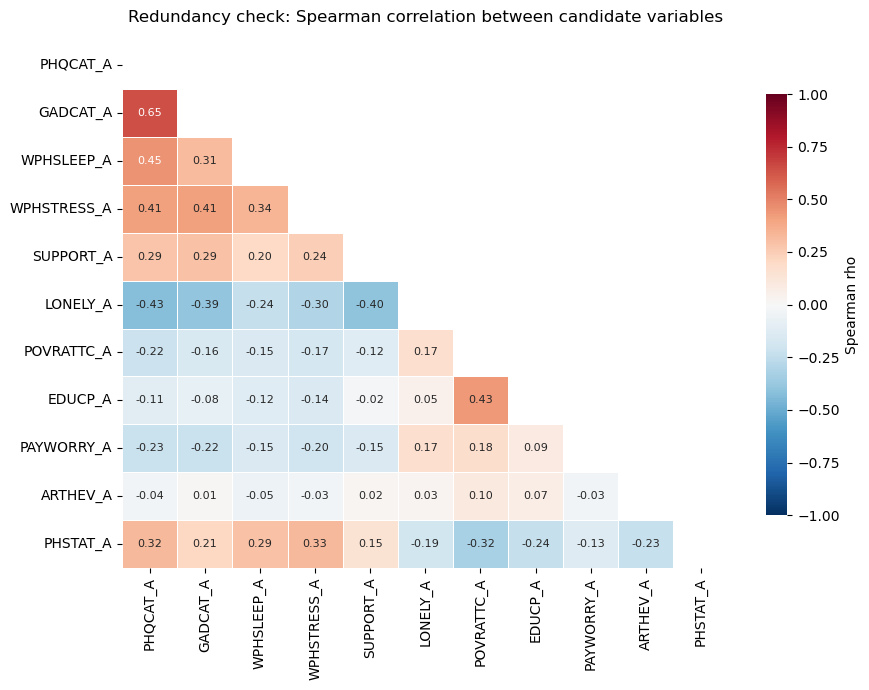

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

spearman_vars = [v for v in candidate_vars if v != "SMKCIGST_A"]
corr = candidates[spearman_vars].corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    mask=mask,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.5,
    cbar_kws={"label": "Spearman rho", "shrink": 0.8},
    ax=ax,
)
ax.set_title("Redundancy check: Spearman correlation between candidate variables", pad=14)
fig.tight_layout()
fig.savefig("../figures/spearman-candidates.png", dpi=200, bbox_inches="tight")

- **PHQCAT_A** and **GADCAT_A**, rho = 0.65. The strongest overlap in the set, which is expected given the relationship between depressive and anxiety symptoms. They remain distinct constructs and neither is a proxy for the other.
  
- **SUPPORT_A** and **LONELY_A**, rho = -0.40. Related but not interchangeable: one asks about the support a person receives, the other about how the person feels.

- **POVRATTC_A** and **EDUCP_A**, rho = 0.43. Two facets of the same socioeconomic dimension.

- **ARTHEV_A** shows very low correlation with every other candidate, which suggests it carries information the others do not. Whether that information helps distinguish HICP is a separate question, and this matrix does not answer it.

NOTES:
1. **LONELY_A** is scored in the opposite direction to the other scales: *a higher value means less loneliness*. This explains its negative correlations throughout and must be kept in mind when reading model coefficients.

2. The target is deliberately absent from this matrix. Candidate variables are selected from the literature and from conceptual reasoning, not from their association with the outcome.

------

## Survey design

In [24]:
survey_design_vars = ["WTFA_A", "PSTRAT", "PPSU"]
df[survey_design_vars].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24215 entries, 0 to 24214
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   WTFA_A  24215 non-null  float64
 1   PSTRAT  24215 non-null  int64  
 2   PPSU    24215 non-null  int64  
dtypes: float64(1), int64(2)
memory usage: 567.7 KB


-> The NHIS is **not a simple random sample**, so these 24,215 respondents are not a small copy of the U.S. adult population. Two things break that:

> Some groups are sampled on purpose more than their share of the population, so that there are enough of them to be analysed separately. Otherwise a group that is small in the country would end up with too few respondents to say anything about.

> Not everyone answers. Non-response may be systematic, as people who are harder to reach or who refuse may differ from those who respond.

> Because of this, the proportions inside the sample are not the proportions in the country. A percentage computed from raw counts is a percentage *of this sample*, not of US adults.


-> The file carries **three variables that describe the design**:

> 'WTFA_A' (page 4) -> final sampling weight. Each respondent stands for a number of US adults, so people from undersampled groups count for more.

> 'PSTRAT' (page 7) -> stratum. The population is split into groups (by geography and other characteristics) and sampled separately within each one, so no part of the country is left out by chance.

> 'PPSU' (page 8) -> primary sampling unit. Respondents are not picked one by one from a national list: geographic areas are selected first, then households inside them.

> **All three are complete (24,215 non-null).**

-> So the counts in this notebook describe the sample I actually have. NCHS publishes weighted prevalence figures, so any number I compare to theirs has to be weighted too.

-> People living in the same area resemble each other more than two people picked at random, so ***the sample carries less independent information than 24,215 unrelated respondents would***. Standard errors and p-values computed as if the sample were independent come out too small. That is what 'PSTRAT' and 'PPSU' are for.

-> I'm not deciding this here. Whether I use the weights, and why, goes in notebook 02.



*******References*******:

*Survey design variables: NHIS 2025 Adult Codebook, pp. 4, 7, 8. Sample design: NHIS 2025 Survey Description, pp. 14, 33–35, 72.*

*Full references in `references/sources.md`.*